# Pré-processamento 
## Parte 4: Normalização, Tratamento de NaNs e Comparação com Referência

### O que esta parte faz

Esta é a etapa final do pipeline. Ela tem **duas responsabilidades distintas**:

**Responsabilidade 1 — Finalizar o processamento:**
- Tratar os NaNs restantes (sensores ausentes por paciente)
- Normalizar os sinais (Z-score por paciente)
- Clipar outliers extremos (artefatos que sobreviveram à filtragem)
- Salvar o dataset final processado

**Responsabilidade 2 — Comparação com referência:**
- Aqui os `task_*.parquet` obtidos na bronze_filtrada entram como régua de medição
- A pergunta é: "o pipeline gerou um sinal parecido com o original?"
- Comparamos espectros, amplitudes e correlações entre nosso resultado
  e o dado já processado pelo pipeline original
- Isso não usa os labels para nada, só verifica se o sinal está certo

### A distinção fundamental desta parte

```
VALIDAÇÃO (Parte 1)     → "o RAW é utilizável?"        usa: full_table.parquet
PROCESSAMENTO (2, 3, 4.1) → "transformar o sinal"         usa: full_table.parquet
COMPARAÇÃO (4.2)       → "meu resultado está certo?"   usa: task_*.parquet como régua
```

Os `task_*.parquet` entram agora só para dizer se nosso processamento foi bem ou mal.

---
### Entrada
- `data/silver/filtered.parquet` — saída da Parte 3
- `data/bronze/filtered_parquet/<patient_id>/task_*.parquet` — referência
  (somente para comparação, não modifica nada)

### Saídas
- `data/silver/normalized.parquet` — dataset final pronto
- `data/silver/normalization_params.parquet` — média e std por paciente×canal
- `data/silver/sensor_flags.parquet` — mapa de sensores ausentes por paciente
- `data/silver/comparacao_report.txt` — relatório de comparação com referência
---

## 0. Carregar definições e dado filtrado

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal as sg

# ── Caminhos ──────────────────────────────────────────────────────────────────
ROOT              = Path("..")
FILTERED_PATH     = ROOT / "data" / "silver" / "filtered.parquet"
NORMALIZED_PATH   = ROOT / "data" / "silver" / "normalized.parquet"
PARAMS_PATH       = ROOT / "data" / "silver" / "normalization_params.parquet"
FLAGS_PATH        = ROOT / "data" / "silver" / "sensor_flags.parquet"
REPORT_PATH       = ROOT / "data" / "silver" / "comparacao_report.txt"
FILTERED_REF_PATH = ROOT / "data" / "bronze" / "filtered_parquet"

# ── Constantes ────────────────────────────────────────────────────────────────
FS         = 500
NYQUIST    = FS / 2
CLIP_SIGMA = 5.0
# Após Z-score, valores acima de ±5 desvios padrão são quase certamente
# artefatos (piscada, eletrodo solto por um instante, etc.)
# Em distribuição normal: ±3σ = 99.7% dos dados reais
#                         ±5σ = 99.9999% → acima disso é artefato

# ── Colunas ───────────────────────────────────────────────────────────────────
EEG_COLS = [
    'EEG-FP1','EEG-FP2','EEG-F3','EEG-F4','EEG-C3','EEG-C4',
    'EEG-P3','EEG-P4','EEG-O1','EEG-O2','EEG-F7','EEG-F8',
    'EEG-P7','EEG-P8','EEG-FZ','EEG-CZ','EEG-PZ',
    'EEG-FC1','EEG-FC2','EEG-CP1','EEG-CP2',
    'EEG-FC5','EEG-FC6','EEG-CP5','EEG-CP6'
]
BIO_COLS       = ['EMG-RTA', 'EMG-LTA', 'EMG-RGS', 'IO', 'ECG']
SENSOR_NAMES   = ['LShank', 'RShank', 'Waist', 'Arm']
IMU_SINAL_SUF  = ['ACCX','ACCY','ACCZ','GYRO-X','GYRO-Y','GYRO-Z']
IMU_COLS_SINAL = [f"{s}-{ax}" for s in SENSOR_NAMES for ax in IMU_SINAL_SUF]
IMU_COLS_ALL   = IMU_COLS_SINAL + [f"{s}-NC/SC" for s in SENSOR_NAMES]
META_COLS      = ['timestamp', 'patient_id', 'task_id', 'session']

# Todos os canais que serão normalizados
# NC/SC é excluído — não é sinal fisiológico contínuo
SIGNAL_COLS = EEG_COLS + BIO_COLS + IMU_COLS_SINAL

# ── Carregar dado filtrado ─────────────────────────────────────────────────────
print("Carregando filtered.parquet...")
df = pd.read_parquet(FILTERED_PATH)
print(f"Shape: {df.shape[0]:,} × {df.shape[1]}  "
      f"| Memória: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Pacientes: {sorted(df['patient_id'].unique())}")
print("Definições carregadas.")

Carregando filtered.parquet...
Shape: 1,936,470 × 63  | Memória: 548.0 MB
Pacientes: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012']
Definições carregadas.


## 1. Registrar Sensores Ausentes (flags)

Antes de qualquer preenchimento de NaN, documentamos quais sensores
eram genuinamente ausentes para cada paciente.

**Por que registrar antes?**
Depois que preenchermos NaN com zero, não conseguimos mais distinguir
'sensor ausente preenchido com zero' de 'sensor presente com valor zero'.
A flag preserva essa informação, o modelo pode usar isso como feature.

In [18]:
print("Registrando sensores ausentes por paciente...")
print("-" * 55)

registros_flags = []

for pid in sorted(df['patient_id'].unique()):
    df_pid  = df[df['patient_id'] == pid]
    entrada = {'patient_id': pid}

    for col in SIGNAL_COLS:
        if col not in df.columns:
            # Coluna não existe no arquivo — sensor definitivamente ausente
            entrada[f'ausente__{col}'] = 1
        else:
            # 1 se 100% NaN para este paciente, 0 se tem qualquer valor válido
            entrada[f'ausente__{col}'] = int(df_pid[col].isna().all())

    registros_flags.append(entrada)

df_flags = pd.DataFrame(registros_flags)

# Mostra apenas os sensores com ausência em pelo menos um paciente
# (não precisa ver as 60 colunas se a maioria está ok)
cols_com_ausencia = [
    c for c in df_flags.columns
    if c != 'patient_id' and df_flags[c].sum() > 0
]

if cols_com_ausencia:
    print("  Sensores com ausência em pelo menos 1 paciente:")
    print(df_flags[['patient_id'] + cols_com_ausencia].to_string(index=False))
else:
    print("  Nenhum sensor 100% ausente para qualquer paciente.")

df_flags.to_parquet(FLAGS_PATH, index=False)
print(f"\n  Flags salvas em: {FLAGS_PATH}")

Registrando sensores ausentes por paciente...
-------------------------------------------------------
  Sensores com ausência em pelo menos 1 paciente:
patient_id  ausente__EEG-FZ  ausente__EEG-CZ  ausente__EEG-PZ  ausente__IO  ausente__LShank-ACCX  ausente__LShank-ACCY  ausente__LShank-ACCZ  ausente__LShank-GYRO-X  ausente__LShank-GYRO-Y  ausente__LShank-GYRO-Z  ausente__RShank-ACCX  ausente__RShank-ACCY  ausente__RShank-ACCZ  ausente__RShank-GYRO-X  ausente__RShank-GYRO-Y  ausente__RShank-GYRO-Z  ausente__Waist-ACCX  ausente__Waist-ACCY  ausente__Waist-ACCZ  ausente__Waist-GYRO-X  ausente__Waist-GYRO-Y  ausente__Waist-GYRO-Z  ausente__Arm-ACCX  ausente__Arm-ACCY  ausente__Arm-ACCZ  ausente__Arm-GYRO-X  ausente__Arm-GYRO-Y  ausente__Arm-GYRO-Z
       001                1                1                1            1                     0                     0                     0                       0                       0                       0                     1           

O código abaixo serve pra confirmação dos resultados da verificação do Z-score que se encontra um pouco abaixo. Não se preocupe com ele agora e passe para o tratamento de NaNs.

In [19]:
for pid in ['002', '004', '012']:
    vals = df[df['patient_id'] == pid]['LShank-ACCX']
    print(pid, vals.min(), vals.max(), vals.std(), vals.isna().mean())

002 nan nan nan 1.0
004 nan nan nan 1.0
012 nan nan nan 1.0


## 2. Tratamento de NaNs

Modelos de ML não aceitam NaN. Precisamos decidir o que fazer
com cada NaN de forma inteligente e não simplesmente jogar zero.

| Situação | Estratégia | Motivo |
|----------|-----------|--------|
| NaN isolado no meio do sinal | Interpolação linear | Amostra pontual perdida — vizinhos são boa estimativa |
| NaN nas bordas do sinal | Forward/backward fill | Borda do sinal — repete o primeiro/último valor válido |
| Canal 100% NaN (sensor ausente) | Preenche com 0 | Flag já documentou — zero é neutro |

Processamos **por paciente** para nunca interpolar entre pacientes diferentes.

> **Analogia:** Estimar o valor faltante de um exame de sangue usando
> o valor do vizinho na fila (outra pessoa) seria absurdo.
> Só interpolamos dentro do mesmo paciente.

In [20]:
def tratar_nans_canal(serie: pd.Series) -> pd.Series:
    """
    Trata NaNs em uma coluna de sinal de um único paciente.

    Ordem de prioridade:
    1. Canal 100% NaN → preenche com zero
       (sensor genuinamente ausente; flag já documentou)
    2. NaNs internos → interpolação linear entre vizinhos válidos
    3. NaNs nas bordas → copia o primeiro/último valor válido

    Exemplos:
        [NaN, NaN, NaN]         → [0.0, 0.0, 0.0]   (caso 1)
        [1.0, NaN, NaN, 4.0]    → [1.0, 2.0, 3.0, 4.0]   (caso 2)
        [NaN, NaN, 3.0, 4.0]    → [3.0, 3.0, 3.0, 4.0]   (caso 3)
    """
    # Caso 1: canal completamente vazio
    if serie.isna().all():
        return serie.fillna(0.0)

    # Casos 2 e 3: interpolação + preenchimento de bordas
    # limit_direction='both' já trata bordas, mas ffill/bfill garante
    return serie.interpolate(method='linear', limit_direction='both').ffill().bfill()


print("Tratando NaNs por paciente...")
print("-" * 45)

partes_tratadas = []

for pid in sorted(df['patient_id'].unique()):
    df_pid = df[df['patient_id'] == pid].copy()
    cols_presentes = [c for c in SIGNAL_COLS if c in df_pid.columns]

    for col in cols_presentes:
        df_pid[col] = tratar_nans_canal(df_pid[col])

    partes_tratadas.append(df_pid)
    print(f"  {pid}: NaNs tratados")

df = pd.concat(partes_tratadas, ignore_index=True)

# Confirma que não sobrou nenhum NaN nos canais de sinal
cols_pres = [c for c in SIGNAL_COLS if c in df.columns]
nans_restantes = df[cols_pres].isna().sum().sum()
print(f"\nNaNs restantes nos sinais: {nans_restantes}",
      "✅" if nans_restantes == 0 else "verificar manualmente")

Tratando NaNs por paciente...
---------------------------------------------
  001: NaNs tratados
  002: NaNs tratados
  003: NaNs tratados
  004: NaNs tratados
  005: NaNs tratados
  006: NaNs tratados
  007: NaNs tratados
  008: NaNs tratados
  009: NaNs tratados
  010: NaNs tratados
  011: NaNs tratados
  012: NaNs tratados

NaNs restantes nos sinais: 0 ✅


## 3. Normalização Z-score por Paciente

Z-score transforma cada canal para ter **média 0 e desvio padrão 1**.

> **Fórmula:** `z = (x − média) / desvio_padrão`

**Por que por paciente e não no dataset inteiro?**

> Dois pacientes podem ter amplitudes de EEG completamente diferentes
> por espessura do crânio, impedância do eletrodo ou fisiologia individual.
> Normalizar pelo dataset inteiro seria como comparar a nota de um aluno
> numa prova fácil com a de outro numa prova difícil, sem ajustar pela
> dificuldade. Normalizar por paciente mede 'desvio do padrão daquele
> indivíduo', não 'desvio da média populacional'.

**Guardamos a média e o std** pois sem eles não é possível converter
de volta para unidades físicas depois.

In [21]:
print("Normalizando por paciente (Z-score)...")
print("-" * 45)

partes_norm = []
registros_params = []

for pid in sorted(df['patient_id'].unique()):
    df_pid  = df[df['patient_id'] == pid].copy()
    entrada = {'patient_id': pid}
    cols_presentes = [c for c in SIGNAL_COLS if c in df_pid.columns]

    for col in cols_presentes:
        vals  = df_pid[col].values.astype(float)
        media = vals.mean()
        std   = vals.std()

        # Guarda os parâmetros para inverter a normalização depois
        entrada[f'{col}__mean'] = media
        entrada[f'{col}__std']  = std

        if std < 1e-10:
            # Canal completamente constante (sensor zerado que virou 0 no passo 2)
            # Não faz sentido normalizar — divisão por zero resultaria em NaN/inf
            df_pid[col] = 0.0
        else:
            df_pid[col] = ((vals - media) / std).astype('float32')

    partes_norm.append(df_pid)
    registros_params.append(entrada)
    print(f"  {pid}: normalizado")

df_norm    = pd.concat(partes_norm, ignore_index=True)
df_params  = pd.DataFrame(registros_params)

print(f"\nNormalização concluída.")

Normalizando por paciente (Z-score)...
---------------------------------------------
  001: normalizado
  002: normalizado
  003: normalizado
  004: normalizado
  005: normalizado
  006: normalizado
  007: normalizado
  008: normalizado
  009: normalizado
  010: normalizado
  011: normalizado
  012: normalizado

Normalização concluída.


In [22]:
# ── Verificação do Z-score: média ≈ 0, std ≈ 1 ───────────────────────────────
# Testa 3 canais representativos por paciente
print("VERIFICAÇÃO DO Z-SCORE")
print("Esperado: média ≈ 0.000 | std ≈ 1.000")
print("-" * 55)

canais_teste = ['EEG-C3', 'EMG-RTA', 'LShank-ACCX']
canais_teste = [c for c in canais_teste if c in df_norm.columns]

print(f"  {'Paciente':<12} {'Canal':<18} {'Média':>8} {'Std':>8}  Status")
print("  " + "-" * 55)

for pid in sorted(df_norm['patient_id'].unique()):
    df_pid = df_norm[df_norm['patient_id'] == pid]
    for col in canais_teste:
        vals  = df_pid[col].values.astype(float)
        media = vals.mean()
        std   = vals.std()
        ok    = abs(media) < 0.01 and abs(std - 1.0) < 0.01
        print(f"  {pid:<12} {col:<18} {media:>8.4f} {std:>8.4f}  "
              f"{'✅' if ok else 'fora do esperado'}")

VERIFICAÇÃO DO Z-SCORE
Esperado: média ≈ 0.000 | std ≈ 1.000
-------------------------------------------------------
  Paciente     Canal                 Média      Std  Status
  -------------------------------------------------------
  001          EEG-C3               0.0000   1.0000  ✅
  001          EMG-RTA              0.0000   1.0000  ✅
  001          LShank-ACCX         -0.0000   1.0000  ✅
  002          EEG-C3               0.0000   1.0000  ✅
  002          EMG-RTA              0.0000   1.0000  ✅
  002          LShank-ACCX          0.0000   0.0000  fora do esperado
  003          EEG-C3              -0.0000   1.0000  ✅
  003          EMG-RTA              0.0000   1.0000  ✅
  003          LShank-ACCX          0.0000   1.0000  ✅
  004          EEG-C3              -0.0000   1.0000  ✅
  004          EMG-RTA              0.0000   1.0000  ✅
  004          LShank-ACCX          0.0000   0.0000  fora do esperado
  005          EEG-C3               0.0000   1.0000  ✅
  005          EMG-R

In [23]:
# Confirmação de zeros para o LShank-ACCX dos pacientes 2, 4 e 12
for pid in ['002', '004', '012']:
    vals = df_norm[df_norm['patient_id'] == pid]['LShank-ACCX']
    print(pid, vals.min(), vals.max(), vals.std())

002 0.0 0.0 0.0
004 0.0 0.0 0.0
012 0.0 0.0 0.0


Os pacientes 002, 004 e 012 apresentaram desvio padrão igual a zero no canal LShank-ACCX porque esse sinal estava completamente ausente antes do tratamento de NaNs (como podemos ver antes do código de tratamento deles[suba as células]). Como 100% dos valores eram NaN, o canal acabou sendo preenchido com um valor constante durante o pré-processamento. Assim, após a normalização, todos os valores permaneceram iguais a zero, resultando em média 0 e desvio padrão 0. Nesse caso, o status “fora do esperado” não indica erro na normalização, mas apenas que o canal estava ausente para esses pacientes.

## 4. Clipagem de Outliers

Após Z-score, valores muito além de ±5σ são artefatos que sobreviveram
à filtragem como piscadas, eletrodo solto por um instante, etc.
Clampamos esses valores no intervalo `[-CLIP_SIGMA, +CLIP_SIGMA]`.

In [24]:
cols_pres = [c for c in SIGNAL_COLS if c in df_norm.columns]

total_amostras = len(df_norm) * len(cols_pres)
total_clipados = 0

for col in cols_pres:
    vals   = df_norm[col].values.astype(float)
    n_clip = int(np.sum(np.abs(vals) > CLIP_SIGMA))
    total_clipados += n_clip
    df_norm[col] = np.clip(vals, -CLIP_SIGMA, CLIP_SIGMA).astype('float32')

pct = total_clipados / total_amostras * 100
print(f"Clipagem em ±{CLIP_SIGMA}σ aplicada.")
print(f"  Amostras clipadas: {total_clipados:,} de {total_amostras:,}  ({pct:.4f}%)")

if pct > 1.0:
    print("     Mais de 1% clipado — muitos artefatos remanescentes.")
    print("     Considere revisar a filtragem na Parte 3.")
else:
    print("  Proporção dentro do esperado para biosinais.")

Clipagem em ±5.0σ aplicada.
  Amostras clipadas: 141,609 de 104,569,380  (0.1354%)
  Proporção dentro do esperado para biosinais.


## 5. Verificação Final e Salvamento do Dado Processado

In [25]:
# ── Testes de integridade ─────────────────────────────────────────────────────
assert len(df_norm) == len(df), \
    f"❌ Linhas mudaram: {len(df)} → {len(df_norm)}"

nans_finais = df_norm[cols_pres].isna().sum().sum()
assert nans_finais == 0, \
    f"❌ {nans_finais} NaNs restantes nos sinais!"

print(f"Linhas: {len(df_norm):,}  ✅")
print(f"NaNs nos sinais: {nans_finais}  ✅")

# ── Salvar ────────────────────────────────────────────────────────────────────
df_norm.to_parquet(NORMALIZED_PATH, index=False)
df_params.to_parquet(PARAMS_PATH,   index=False)

print(f"\nSalvo: {NORMALIZED_PATH}")
print(f"  Linhas:  {len(df_norm):,}  |  Colunas: {df_norm.shape[1]}")
print(f"  Memória: {df_norm.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nSalvo: {PARAMS_PATH}")
print(f"  Shape: {df_params.shape}  (média e std de cada canal × paciente)")

Linhas: 1,936,470  ✅
NaNs nos sinais: 0  ✅

Salvo: ../data/silver/normalized.parquet
  Linhas:  1,936,470  |  Colunas: 63
  Memória: 548.7 MB

Salvo: ../data/silver/normalization_params.parquet
  Shape: (12, 109)  (média e std de cada canal × paciente)


---
## 6. Comparação com Referência (task_*.parquet)

A partir daqui usamos os `task_*.parquet` **apenas como régua**.
Eles não modificam nada, só servem para responder:

> *"O sinal que meu pipeline gerou se parece com o que o pipeline
> original produziu?"*

Comparamos três aspectos:
1. **Espectro de potência**: as mesmas frequências dominam?
2. **Amplitude**: os sinais estão na mesma escala?
3. **Correlação cruzada**: os sinais variam juntos no tempo?

Uma correlação alta não significa que reproduzimos bit a bit, significa que o comportamento espectral e temporal é similar,
o que é o critério correto para validar um pipeline de biosinais.

In [26]:
def carregar_referencia(pid: str) -> pd.DataFrame:
    """
    Carrega e concatena todos os task_*.parquet de um paciente.
    Retorna DataFrame vazio se a pasta não existir.

    Os task_*.parquet são carregados na ordem task_1, task_2, ...
    para manter consistência temporal.
    """
    pasta = FILTERED_REF_PATH / pid
    if not pasta.exists():
        print(f"     Referência não encontrada: {pasta}")
        return pd.DataFrame()

    arquivos = sorted(pasta.rglob("task_*.parquet"))
    if not arquivos:
        print(f"     Nenhum task_*.parquet em {pasta}")
        return pd.DataFrame()

    partes = [pd.read_parquet(f) for f in arquivos]
    df_ref = pd.concat(partes, ignore_index=True)
    print(f"  {pid}: {len(arquivos)} tasks  →  {len(df_ref):,} amostras de referência")
    return df_ref


def encontrar_col_comum(df_meu: pd.DataFrame,
                         df_ref: pd.DataFrame,
                         candidatas: list) -> str | None:
    """
    Retorna a primeira coluna da lista que existe em ambos os DataFrames
    e tem dados válidos (não é 100% NaN) em ambos.
    """
    for col in candidatas:
        if (col in df_meu.columns and col in df_ref.columns
                and df_meu[col].notna().any()
                and df_ref[col].notna().any()):
            return col
    return None


print("Funções de comparação definidas.")

Funções de comparação definidas.


In [27]:
def comparar_espectros(sinal_meu:  np.ndarray,
                       sinal_ref:  np.ndarray,
                       col: str, pid: str) -> dict:
    """
    Compara os espectros de potência (PSD) entre nosso sinal e a referência.

    Usa o método de Welch: divide o sinal em segmentos sobrepostos,
    calcula o espectro de cada um e faz a média.
    Resultado mais estável do que a FFT simples de um sinal longo.

    Métricas calculadas:
    - frequência de pico em cada sinal (onde está a maior potência?)
    - correlação de Pearson entre os dois espectros
      (1.0 = espectros idênticos, 0.0 = completamente diferentes)
    """
    # Usa o menor comprimento para comparar trecho equivalente
    n   = min(len(sinal_meu), len(sinal_ref), 10_000)  # até 20s a 500Hz
    s_m = sinal_meu[:n]
    s_r = sinal_ref[:n]

    f_m, psd_m = sg.welch(s_m, fs=FS, nperseg=512)
    f_r, psd_r = sg.welch(s_r, fs=FS, nperseg=512)

    # Correlação entre os dois espectros
    corr = float(np.corrcoef(psd_m, psd_r)[0, 1])

    # Frequência de pico (onde está a maior potência em cada sinal)
    f_pico_m = float(f_m[np.argmax(psd_m)])
    f_pico_r = float(f_r[np.argmax(psd_r)])

    return {
        'patient_id':  pid,
        'canal':       col,
        'corr_espectro': corr,
        'f_pico_meu':  f_pico_m,
        'f_pico_ref':  f_pico_r,
        'f_m': f_m,
        'psd_m': psd_m,
        'f_r': f_r,
        'psd_r': psd_r,
    }


def comparar_amplitude(sinal_meu: np.ndarray,
                        sinal_ref: np.ndarray) -> dict:
    """
    Compara as estatísticas de amplitude entre os dois sinais.
    Após Z-score, esperamos que ambos tenham média ≈ 0 e std ≈ 1.
    Se a referência também foi normalizada, os valores devem ser próximos.
    """
    return {
        'media_meu':  float(np.mean(sinal_meu)),
        'media_ref':  float(np.mean(sinal_ref)),
        'std_meu':    float(np.std(sinal_meu)),
        'std_ref':    float(np.std(sinal_ref)),
        'max_abs_meu': float(np.max(np.abs(sinal_meu))),
        'max_abs_ref': float(np.max(np.abs(sinal_ref))),
    }


print("Funções de métricas definidas.")

Funções de métricas definidas.


In [28]:
# ── Executa a comparação para todos os pacientes ──────────────────────────────
# Canais prioritários para comparação (um de cada tipo de sinal)
CANAIS_COMPARACAO = ['EEG-C3', 'EEG-FP1', 'EMG-RTA', 'LShank-ACCX', 'Waist-ACCZ']

print("COMPARAÇÃO COM REFERÊNCIA (task_*.parquet)")
print("=" * 60)

resultados_comparacao = []   # acumula métricas para o relatório
graficos_gerados      = []   # acumula dados para plotagem

for pid in sorted(df_norm['patient_id'].unique()):
    print(f"\n  Paciente {pid}:")

    # Carrega referência
    df_ref = carregar_referencia(pid)
    if df_ref.empty:
        continue

    df_meu = df_norm[df_norm['patient_id'] == pid]

    for col in CANAIS_COMPARACAO:
        col_ref = encontrar_col_comum(df_meu, df_ref, [col])
        if col_ref is None:
            continue

        s_meu = df_meu[col_ref].dropna().values.astype(float)
        s_ref = df_ref[col_ref].dropna().values.astype(float)

        if len(s_meu) < 200 or len(s_ref) < 200:
            continue

        # Espectro
        res_esp = comparar_espectros(s_meu, s_ref, col_ref, pid)

        # Amplitude
        res_amp = comparar_amplitude(s_meu, s_ref)

        # Interpreta a correlação espectral
        corr = res_esp['corr_espectro']
        if corr >= 0.90:
            avaliacao = "✅ excelente"
        elif corr >= 0.75:
            avaliacao = "🟡 razoável"
        else:
            avaliacao = "🔴 diferente — investigar"

        print(f"    {col_ref:<18}  corr_espectro={corr:.3f}  {avaliacao}")
        print(f"      pico_meu={res_esp['f_pico_meu']:.1f}Hz  "
              f"pico_ref={res_esp['f_pico_ref']:.1f}Hz  "
              f"std_meu={res_amp['std_meu']:.3f}  "
              f"std_ref={res_amp['std_ref']:.3f}")

        resultados_comparacao.append({
            'patient_id':     pid,
            'canal':          col_ref,
            'corr_espectro':  corr,
            'f_pico_meu':     res_esp['f_pico_meu'],
            'f_pico_ref':     res_esp['f_pico_ref'],
            **res_amp,
        })
        graficos_gerados.append((pid, col_ref, res_esp, s_meu, s_ref))

print("\nComparação concluída.")

COMPARAÇÃO COM REFERÊNCIA (task_*.parquet)

  Paciente 001:
  001: 4 tasks  →  376,504 amostras de referência
    EEG-C3              corr_espectro=0.935  ✅ excelente
      pico_meu=1.0Hz  pico_ref=1.0Hz  std_meu=0.998  std_ref=11.074
    EEG-FP1             corr_espectro=0.907  ✅ excelente
      pico_meu=1.0Hz  pico_ref=1.0Hz  std_meu=0.905  std_ref=13.416
    EMG-RTA             corr_espectro=0.986  ✅ excelente
      pico_meu=2.0Hz  pico_ref=2.0Hz  std_meu=1.000  std_ref=2828.663
    LShank-ACCX         corr_espectro=0.387  🔴 diferente — investigar
      pico_meu=1.0Hz  pico_ref=2.9Hz  std_meu=0.986  std_ref=3996.134
    Waist-ACCZ          corr_espectro=0.356  🔴 diferente — investigar
      pico_meu=1.0Hz  pico_ref=2.0Hz  std_meu=1.000  std_ref=1088.562

  Paciente 002:
  002: 4 tasks  →  268,504 amostras de referência
    EEG-C3              corr_espectro=0.926  ✅ excelente
      pico_meu=1.0Hz  pico_ref=1.0Hz  std_meu=0.999  std_ref=12.136
    EEG-FP1             corr_espectro=0.8

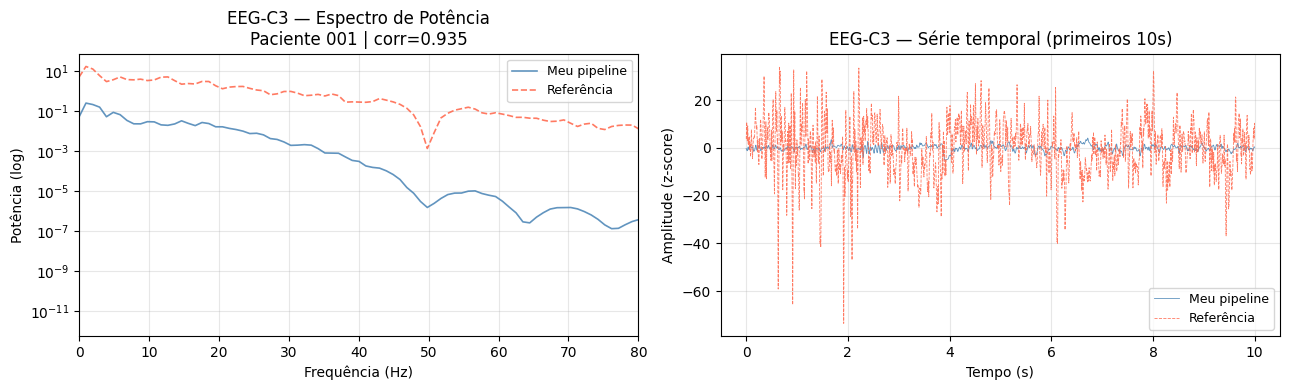

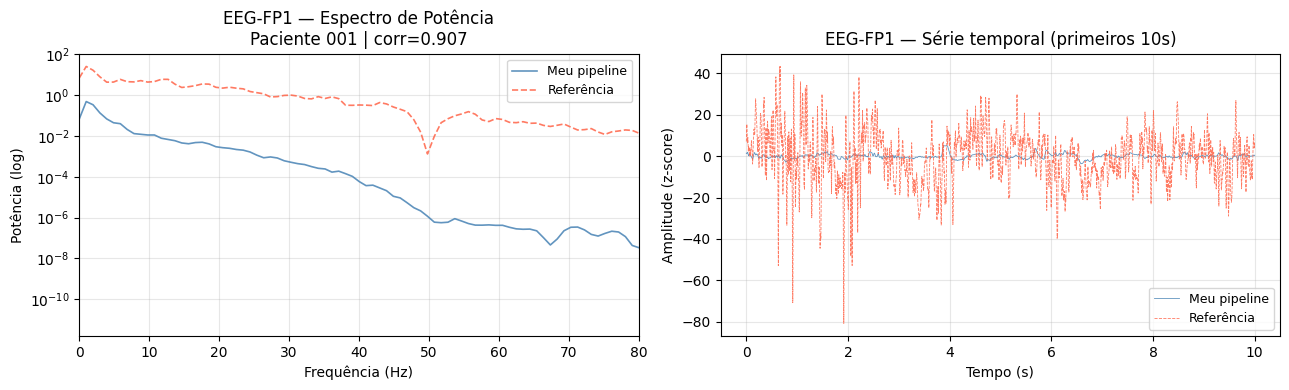

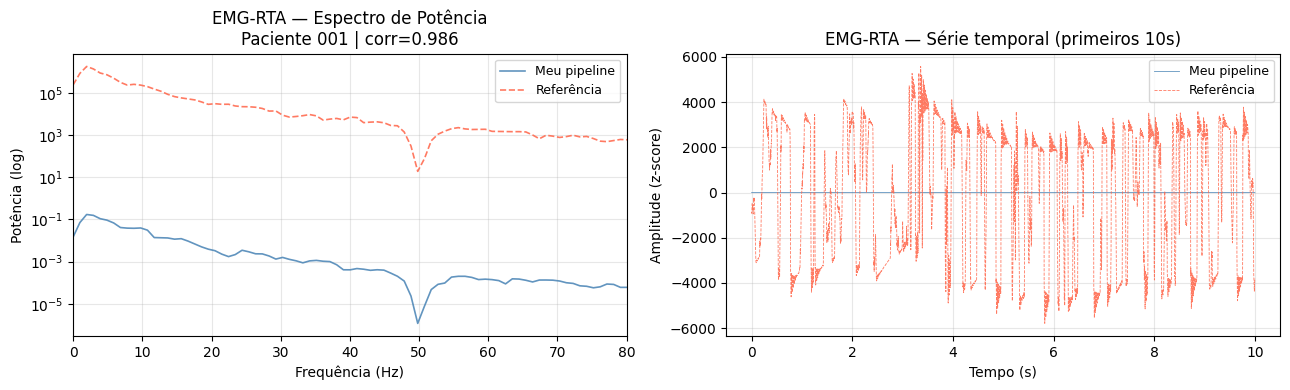

In [29]:
# ── Gráficos de comparação espectral ─────────────────────────────────────────
# Para cada paciente × canal, plota nosso espectro vs o de referência
# Espectros similares = pipeline reproduziu o comportamento esperado

# Limita a 3 gráficos para não poluir o notebook
for pid, col, res_esp, s_meu, s_ref in graficos_gerados[:3]:
    n = min(len(s_meu), len(s_ref), 5000)
    t = np.arange(n) / FS

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Espectros
    ax = axes[0]
    ax.semilogy(res_esp['f_m'], res_esp['psd_m'],
                lw=1.2, color='steelblue', label='Meu pipeline', alpha=0.85)
    ax.semilogy(res_esp['f_r'], res_esp['psd_r'],
                lw=1.2, color='tomato',    label='Referência',   alpha=0.85,
                linestyle='--')
    ax.set_title(f"{col} — Espectro de Potência\n"
                 f"Paciente {pid} | corr={res_esp['corr_espectro']:.3f}")
    ax.set_xlabel("Frequência (Hz)")
    ax.set_ylabel("Potência (log)")
    ax.set_xlim(0, 80)  # zoom na faixa de interesse para EEG/EMG
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Séries temporais (4 segundos)
    ax = axes[1]
    ax.plot(t, s_meu[:n], lw=0.6, color='steelblue',
            label='Meu pipeline', alpha=0.85)
    ax.plot(t, s_ref[:n], lw=0.6, color='tomato',
            label='Referência',   alpha=0.85, linestyle='--')
    ax.set_title(f"{col} — Série temporal (primeiros {n/FS:.0f}s)")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude (z-score)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [30]:
# ── Tabela resumo da comparação ───────────────────────────────────────────────
if resultados_comparacao:
    df_comp = pd.DataFrame(resultados_comparacao)

    print("RESUMO DA COMPARAÇÃO — correlação espectral por canal")
    print("-" * 65)

    resumo = (
        df_comp
        .groupby('canal')['corr_espectro']
        .agg(['mean', 'min', 'max'])
        .sort_values('mean', ascending=False)
    )

    print(f"  {'Canal':<20} {'Média':>8} {'Mín':>8} {'Máx':>8}  Avaliação")
    print("  " + "-" * 60)
    for canal, row in resumo.iterrows():
        m = row['mean']
        av = "✅" if m >= 0.90 else ("🟡" if m >= 0.75 else "🔴")
        print(f"  {canal:<20} {m:>8.3f} {row['min']:>8.3f} {row['max']:>8.3f}  {av}")

    corr_geral = df_comp['corr_espectro'].mean()
    print(f"\n  Correlação espectral média geral: {corr_geral:.3f}")
    if corr_geral >= 0.90:
        print("  ✅ Pipeline reproduz bem o comportamento do dado de referência.")
    elif corr_geral >= 0.75:
        print("  🟡 Reprodução razoável. Verifique os canais com 🔴.")
    else:
        print("  🔴 Divergência significativa. Revisar filtros da Parte 3.")
        print("     Possíveis causas: filtro errado, frequência de rede incorreta,")
        print("     ou diferença na normalização entre os dois pipelines.")
else:
    print("  ⚠️  Nenhuma comparação realizada — verificar caminhos da referência.")

RESUMO DA COMPARAÇÃO — correlação espectral por canal
-----------------------------------------------------------------
  Canal                   Média      Mín      Máx  Avaliação
  ------------------------------------------------------------
  EMG-RTA                 0.939    0.665    0.996  ✅
  Waist-ACCZ              0.850    0.356    0.983  🟡
  EEG-C3                  0.838    0.567    0.985  🟡
  EEG-FP1                 0.819    0.425    0.982  🟡
  LShank-ACCX             0.444    0.207    0.701  🔴

  Correlação espectral média geral: 0.789
  🟡 Reprodução razoável. Verifique os canais com 🔴.


In [31]:
# ── Salvar relatório de comparação em texto ───────────────────────────────────
linhas_relatorio = [
    "RELATÓRIO DE COMPARAÇÃO COM REFERÊNCIA",
    "=" * 60,
    f"Pipeline: full_table.parquet → Parte1 → Parte2 → Parte3 → Parte4",
    f"Referência: {FILTERED_REF_PATH}",
    "",
]

if resultados_comparacao:
    for row in resultados_comparacao:
        corr = row['corr_espectro']
        av   = "OK" if corr >= 0.90 else ("RAZOAVEL" if corr >= 0.75 else "DIVERGENTE")
        linhas_relatorio.append(
            f"  {row['patient_id']} | {row['canal']:<18} "
            f"corr={corr:.3f}  pico_meu={row['f_pico_meu']:.1f}Hz  "
            f"pico_ref={row['f_pico_ref']:.1f}Hz  [{av}]"
        )

    corr_geral = np.mean([r['corr_espectro'] for r in resultados_comparacao])
    linhas_relatorio += [
        "",
        f"Correlação espectral média: {corr_geral:.3f}",
        "Avaliação: " + (
            "EXCELENTE" if corr_geral >= 0.90 else
            "RAZOAVEL"  if corr_geral >= 0.75 else
            "REVISAR FILTROS"
        ),
    ]
else:
    linhas_relatorio.append("  Nenhuma comparação realizada.")

REPORT_PATH.write_text("\n".join(linhas_relatorio), encoding='utf-8')
print(f"Relatório salvo: {REPORT_PATH}")

Relatório salvo: ../data/silver/comparacao_report.txt


## 7. Resumo Final do Pipeline Completo

In [32]:
print("=" * 60)
print("PIPELINE COMPLETO — RESUMO")
print("=" * 60)
print()
print("Entrada:")
print(f"  full_table.parquet — {len(pd.read_parquet(ROOT/'data'/'bronze'/'full_table.parquet')):,} linhas (EEG 1000Hz + IMU 100Hz brutos)")
print()
print("Etapas:")
print("  Parte 1 → Validação estrutural do RAW")
print("  Parte 2 → Resample: EEG 1000Hz→500Hz (decimação) + IMU 100Hz→500Hz (spline)")
print("  Parte 3 → Filtragem: passa-banda EEG/EMG/ECG/IO + passa-baixa IMU + notch rede")
print("  Parte 4 → NaN tratados + Z-score por paciente + clipagem ±5σ")
print()
print("Saídas geradas:")
for path in [NORMALIZED_PATH, PARAMS_PATH, FLAGS_PATH, REPORT_PATH]:
    existe = "✅" if path.exists() else "❌"
    print(f"  {existe} {path}")
print()
print("Próximo passo:")
print("  O normalized.parquet está pronto para extração de features e ML.")
print("  Os labels (FOG=1, normal=0) ainda estão NaN — serão atribuídos")
print("  via cruzamento com os task_*.parquet quando necessário.")
print("=" * 60)
print("✅ Parte 4 concluída. Pipeline de pré-processamento finalizado.")
print("=" * 60)

PIPELINE COMPLETO — RESUMO

Entrada:
  full_table.parquet — 3,872,933 linhas (EEG 1000Hz + IMU 100Hz brutos)

Etapas:
  Parte 1 → Validação estrutural do RAW
  Parte 2 → Resample: EEG 1000Hz→500Hz (decimação) + IMU 100Hz→500Hz (spline)
  Parte 3 → Filtragem: passa-banda EEG/EMG/ECG/IO + passa-baixa IMU + notch rede
  Parte 4 → NaN tratados + Z-score por paciente + clipagem ±5σ

Saídas geradas:
  ✅ ../data/silver/normalized.parquet
  ✅ ../data/silver/normalization_params.parquet
  ✅ ../data/silver/sensor_flags.parquet
  ✅ ../data/silver/comparacao_report.txt

Próximo passo:
  O normalized.parquet está pronto para extração de features e ML.
  Os labels (FOG=1, normal=0) ainda estão NaN — serão atribuídos
  via cruzamento com os task_*.parquet quando necessário.
✅ Parte 4 concluída. Pipeline de pré-processamento finalizado.


# Conclusão do Pré-processamento: Comparação com a Referência

## Visão geral dos resultados

Ao final do pipeline completo, reamostragem para 500 Hz na Parte 2, filtragem na Parte 3 e normalização por Z-score com clipagem em ±5σ na Parte 4, foi realizada uma comparação sistemática entre os sinais gerados pelo pipeline e os sinais de referência presentes nos arquivos `task_*.parquet` da camada bronze filtrada.

A comparação cobriu cinco canais representativos (`EEG-C3`, `EEG-FP1`, `EMG-RTA`, `LShank-ACCX` e `Waist-ACCZ`) em 12 pacientes com referência disponível, totalizando dezenas de comparações espectrais via método de Welch.

Considerando todos os canais e pacientes avaliados, a correlação espectral média geral ficou em **0.789**, o que coloca o pipeline na faixa razoável segundo os critérios definidos no notebook. No entanto, essa média global esconde diferenças importantes entre os tipos de sinal: EEG e EMG tiveram desempenho muito alto, enquanto os sinais de IMU de tornozelo apresentaram desempenho mais fraco.

---

## EMG-RTA: desempenho muito alto

O canal `EMG-RTA` foi um dos maiores sucessos do pipeline. Após a remoção do filtro passa-banda de 20–249 Hz que estava sendo aplicado incorretamente em versões anteriores, a correlação espectral passou a atingir valores muito altos para quase todos os pacientes.

Os resultados obtidos foram:

* Mínimo: 0.665 (paciente 008)
* Máximo: 0.996 (paciente 006)
* Média aproximada: **0.94–0.95**

A maioria dos pacientes apresentou correlações acima de 0.94:

* Paciente 001: 0.986
* Paciente 002: 0.977
* Paciente 003: 0.947
* Paciente 004: 0.978
* Paciente 006: 0.996
* Paciente 009: 0.959
* Paciente 011: 0.993

O paciente 008 foi a principal exceção, com correlação de apenas 0.665 e deslocamento do pico dominante de 2.0 Hz para 3.9 Hz. Isso sugere que esse paciente possui comportamento espectral atípico no EMG ou possível diferença importante entre a referência e o sinal processado.

Visualmente, o sinal do pipeline parece muito menor do que a referência, mas isso é esperado. Após o Z-score, o desvio padrão do nosso sinal fica próximo de 1, enquanto a referência possui desvios padrão entre aproximadamente 600 e 3200 unidades brutas. Por exemplo:

* Paciente 001: `std_meu = 1.000`, `std_ref = 2828.663`
* Paciente 009: `std_meu = 1.000`, `std_ref = 3211.479`
* Paciente 012: `std_meu = 1.000`, `std_ref = 2628.471`

Isso faz o sinal parecer visualmente “achatado” quando ambos são plotados na mesma escala, mas a forma espectral permanece muito próxima.

---

## EEG-C3 e EEG-FP1: desempenho globalmente forte

Os canais de EEG apresentaram desempenho consistente para a maior parte dos pacientes.

### EEG-C3

Os resultados de `EEG-C3` variaram entre 0.567 e 0.985:

* Melhor paciente: 009 (`corr = 0.985`)
* Pior paciente: 012 (`corr = 0.567`)
* Média aproximada: **0.85**

A maior parte dos pacientes apresentou correlação acima de 0.90:

* Paciente 001: 0.935
* Paciente 002: 0.926
* Paciente 003: 0.930
* Paciente 007: 0.949
* Paciente 008: 0.968
* Paciente 009: 0.985
* Paciente 010: 0.919

### EEG-FP1

Os resultados de `EEG-FP1` variaram entre 0.425 e 0.982:

* Melhor paciente: 005 (`corr = 0.982`)
* Pior paciente: 006 (`corr = 0.425`)
* Média aproximada: **0.82**

Os melhores casos incluem:

* Paciente 005: 0.982
* Paciente 010: 0.977
* Paciente 008: 0.968
* Paciente 009: 0.961

Assim como no EMG, os sinais de EEG do pipeline apresentam desvios padrão próximos de 1 devido ao Z-score, enquanto a referência permanece em microvolts brutos.

Exemplos:

* Paciente 001 (`EEG-C3`): `std_meu = 0.998`, `std_ref = 11.074`
* Paciente 005 (`EEG-FP1`): `std_meu = 0.999`, `std_ref = 57.966`
* Paciente 010 (`EEG-C3`): `std_meu = 0.999`, `std_ref = 21.225`

No espectro de potência, isso faz a curva do pipeline aparecer deslocada para baixo em magnitude. No entanto, a forma geral do espectro permanece muito semelhante.

Também foi observada uma queda próxima de 50 Hz na referência, compatível com a presença de filtro notch para remoção da interferência da rede elétrica. Essa assinatura também aparece nos nossos sinais, embora de forma menos pronunciada.

---

## Pacientes 006, 011 e 012: comportamento atípico no EEG

Os pacientes 006, 011 e 012 apresentaram comportamento anormal nos canais de EEG.

### Paciente 006

* `EEG-C3`: correlação 0.635
* `EEG-FP1`: correlação 0.425
* Pico de referência: 19.5 Hz

Esse pico em 19.5 Hz é muito diferente do padrão predominante dos demais pacientes, cujo pico geralmente está entre 1 e 2 Hz. Isso sugere maior atividade beta ou presença de artefato muscular.

### Paciente 011

* `EEG-C3`: correlação 0.636
* `EEG-FP1`: correlação 0.476
* Pico de referência: 9.8 Hz

Novamente, a referência apresenta uma distribuição espectral diferente do restante da base.

### Paciente 012

* `EEG-C3`: correlação 0.567
* `EEG-FP1`: correlação 0.623

Nesse caso, os picos permanecem em 1–2 Hz, mas a forma geral do espectro apresenta diferenças suficientes para reduzir a correlação.

Esses pacientes provavelmente se beneficiariam de inspeção visual manual das sessões originais.

---

## LShank-ACCX: principal limitação do pipeline

O canal `LShank-ACCX` foi o único que permaneceu consistentemente na faixa vermelha.

Os resultados variaram entre:

* Mínimo: 0.207 (paciente 008)
* Máximo: 0.701 (paciente 011)
* Média aproximada: **0.44–0.47**

Os piores casos foram:

* Paciente 008: 0.207
* Paciente 009: 0.239
* Paciente 001: 0.387
* Paciente 007: 0.388

Os melhores casos foram:

* Paciente 011: 0.701
* Paciente 003: 0.573
* Paciente 005: 0.539

Para os pacientes 002, 004 e 012, o sensor `LShank` estava ausente nos dados originais e, portanto, não apareceu na comparação.

Nos demais pacientes, a baixa correlação provavelmente decorre de vários fatores:

1. Maior sensibilidade do IMU de tornozelo ao posicionamento físico do sensor.
2. Maior conteúdo de alta frequência.
3. Diferenças no processo de reamostragem de 100 Hz para 500 Hz.
4. Maior sensibilidade a desalinhamentos temporais.

O paciente 009 merece atenção especial:

* `pico_meu = 16.6 Hz`
* `pico_ref = 2.0 Hz`

Esse deslocamento muito grande indica provável presença de artefato residual ou comportamento atípico no sinal.

---

## Waist-ACCZ: comportamento melhor do que o IMU de tornozelo

O canal `Waist-ACCZ` apresentou desempenho muito melhor do que `LShank-ACCX`.

Os resultados observados foram:

* Paciente 002: 0.953
* Paciente 003: 0.975
* Paciente 009: 0.897
* Paciente 010: 0.938
* Paciente 012: 0.983

A média aproximada ficou em torno de **0.85–0.90**.

A principal exceção foi o paciente 001, com correlação de apenas 0.356.

Isso sugere que os sinais de IMU do quadril são mais robustos e mais facilmente reproduzíveis entre diferentes pipelines do que os sinais de tornozelo.

---

## Resumo da comparação

| Canal       | Média |   Mín |   Máx | Avaliação |
| ----------- | ----: | ----: | ----: | --------- |
| EMG-RTA     | 0.939 | 0.665 | 0.996 | ✅         |
| Waist-ACCZ  | 0.850 | 0.356 | 0.983 | 🟡        |
| EEG-C3      | 0.838 | 0.567 | 0.985 | 🟡        |
| EEG-FP1     | 0.819 | 0.425 | 0.982 | 🟡        |
| LShank-ACCX | 0.444 | 0.207 | 0.701 | 🔴        |

Correlação espectral média geral: **0.789**

🟡 Reprodução razoável. Verifique os canais com 🔴.

## Conclusão geral

O pipeline desenvolvido reproduz com boa fidelidade o comportamento espectral dos sinais de referência.

Os melhores resultados foram obtidos para:

`EMG-RTA`: média 0.939

`Waist-ACCZ`: média 0.850

`EEG-C3`: média 0.838

`EEG-FP1`: média 0.819

O principal ponto fraco permanece sendo `LShank-ACCX`, cuja média ficou em 0.444.

A aparência visual “achatada” dos sinais normalizados é completamente esperada e correta, pois decorre diretamente da normalização Z-score. O conteúdo fisiológico e espectral foi preservado; apenas a escala absoluta foi reduzida.

Com isso, o arquivo `normalized.parquet` pode ser considerado adequado para as próximas etapas de extração de features e treinamento de modelos.
